# Exercise 1 — Predict Whether a Student Will Pass

## Goal

Build a **binary classification neural network** that predicts whether a student will pass based on:

- `hours_studied`
- `attendance`
- `previous_score`

Target:

- `0` = Fail
- `1` = Pass

### Neural network

```text
hours_studied ───┐
attendance ──────┼──> Dense → ReLU → Dense → Sigmoid → Pass/Fail
previous_score ──┘
```

## Concepts practiced

- neurons
- weights
- biases
- forward propagation
- ReLU
- sigmoid
- binary cross-entropy
- gradient descent
- backpropagation
- epochs
- batches

> **Important:** We will first understand the problem and data, then build the neural network using Keras/TensorFlow.


## 1. The problem

Imagine a school wants to identify students who may be at risk of failing.

For each student, we know:

| Feature | Meaning |
|---|---|
| `hours_studied` | Average study hours per day |
| `attendance` | Attendance percentage |
| `previous_score` | Previous exam/course score |

The model should learn:

```text
Student information
        ↓
Neural network
        ↓
Probability of passing
        ↓
Pass / Fail
```

### Question

Why is this a **classification** problem rather than a regression problem?


## 2. Load the dataset

The dataset is in:

`student_pass_dataset.csv`

###  task

Load the CSV into a pandas DataFrame and display the first 10 rows.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("student_pass_dataset.csv")
df.head()

,student_id,hours_studied,attendance,previous_score,passed
0,1,0.9,81.0,64.6,0
1,2,5.7,83.9,83.4,1
2,3,4.5,100.0,51.5,1
3,4,4.8,100.0,71.3,0
4,5,3.4,59.3,57.2,0


## 3. Explore the data

Answer these questions:

1. How many students are in the dataset?
2. What are the input features?
3. What is the target?
4. Are there missing values?
5. How many students passed?
6. How many students failed?

In [20]:
df.shape, df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   student_id      600 non-null    int64  
 1   hours_studied   600 non-null    float64
 2   attendance      600 non-null    float64
 3   previous_score  600 non-null    float64
 4   passed          600 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 23.6 KB


((600, 5), None)

In [21]:
df.isnull().sum()

student_id        0
hours_studied     0
attendance        0
previous_score    0
passed            0
dtype: int64

In [22]:
df["passed"].value_counts()

passed
0    400
1    200
Name: count, dtype: int64

## 4. Separate inputs and target

The neural network needs:

```text
X = input features
y = target
```

Use the three columns:

```text
hours_studied
attendance
previous_score
```

as `X`.

Use:

```text
passed
```

as `y`.

### Question

Why should `student_id` NOT be used as an input feature?


In [23]:
X = df.drop(['student_id', 'passed'], axis=1)
y = df['passed']

it is a unique identifier with no predictive value.

## 5. Train/test split

We need to evaluate the model on students it has not seen during training.

Use:

- 80% training data
- 20% testing data
- `random_state=42`
- `stratify=y`

Why is `stratify=y` useful for a classification problem?


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((450, 3), (150, 3), (450,), (150,))

ensures that our train and test sets keep the same class proportions as our original dataset. 

## 6. Scale the features

Notice that our features have different ranges:

```text
hours_studied   → roughly 0–12
attendance      → roughly 35–100
previous_score  → roughly 20–100
```

Neural networks usually train more effectively when numerical inputs are on similar scales.

Use `StandardScaler`.

**Important:** fit the scaler only on the training data, then transform both training and test data.


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

## 7. Build the neural network

Create this architecture:

```text
Input: 3 features
       ↓
Dense(8)
       ↓
ReLU
       ↓
Dense(4)
       ↓
ReLU
       ↓
Dense(1)
       ↓
Sigmoid
       ↓
Probability of passing
```

### Think about the layers

- Why are there 3 input values?
- Why do we use ReLU in the hidden layers?
- Why does the final layer have only 1 neuron?
- Why do we use sigmoid at the output?


In [26]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(8, activation="relu", input_shape=(3,)),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

C:\Users\Sami\Documents\PROJECTS\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

* Because we have 3 features for each student
* It helps the network learn non-linear patterns.
* Because we are predicting one thing: pass or fail.
* It converts the output to a probability between 0 and 1.

## 8. Compile the model

Use:

- optimizer: `adam`
- loss: `binary_crossentropy`
- metric: `accuracy`

### Important concept

During training:

```text
prediction
    ↓
binary cross-entropy
    ↓
loss
    ↓
backpropagation
    ↓
gradients
    ↓
update weights
```

The optimizer uses the gradients to update the network's weights.


In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 9. Train the model

Train for around **50 epochs** with:

- batch size = 16
- validation split = 20%

Watch the training and validation loss.

### Questions

1. Does the loss generally decrease?
2. What does one epoch mean?
3. What does the batch size control?
4. Why might training accuracy continue increasing while validation accuracy stops improving?


In [29]:
history = model.fit(
    scaled_x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
 )

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6028 - loss: 0.6835 - val_accuracy: 0.5556 - val_loss: 0.6886
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6778 - loss: 0.6682 - val_accuracy: 0.6000 - val_loss: 0.6791
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6833 - loss: 0.6524 - val_accuracy: 0.6000 - val_loss: 0.6684
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6833 - loss: 0.6375 - val_accuracy: 0.6000 - val_loss: 0.6566
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6833 - loss: 0.6219 - val_accuracy: 0.6000 - val_loss: 0.6446
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6833 - loss: 0.6058 - val_accuracy: 0.6000 - val_loss: 0.6316
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6861 - loss: 0.5896 - val_accuracy: 0.6111 - val_loss: 0.6194
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6917 - loss: 0.5730 - val_accuracy: 0.6222 - val_loss

* Yes. It should generally decrease as the model learns. it fluctuates though sometime.
* the model sees the entire training dataset once.
* It controls how many samples are processed before the weights are updated.
* The model may be overfitting

## 10. Plot the learning curves

Plot:

1. training loss vs validation loss
2. training accuracy vs validation accuracy

Look for evidence of:

- learning
- underfitting
- overfitting


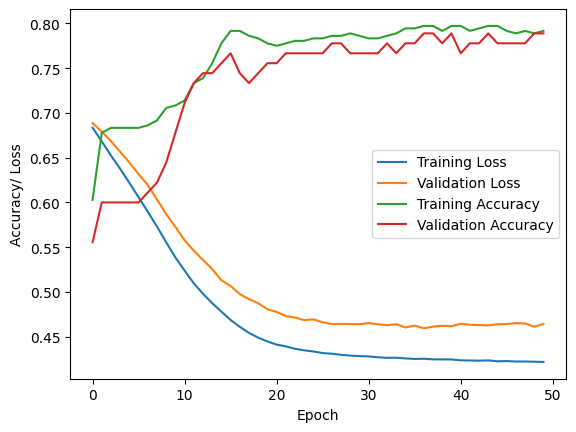

In [32]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.ylabel("Accuracy/ Loss")
plt.xlabel("Epoch")
plt.legend()

## 11. Evaluate on the test set

Calculate:

- test loss
- test accuracy

Remember:

> The test set should represent data the model did not use to learn its weights.


In [34]:
test_loss, test_accuracy = model.evaluate( scaled_x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8267 - loss: 0.4191 
Test Loss: 0.4190880358219147
Test Accuracy: 0.8266666531562805


## 12. Make predictions

The sigmoid output is a probability between 0 and 1.

For example:

```text
0.92 → likely pass
0.18 → likely fail
```

Use a threshold of `0.5`:

```python
prediction >= 0.5 → 1
prediction < 0.5  → 0
```

Make predictions for the test set.


In [35]:
y_prob = model.predict(scaled_x_test)
y_pred = (y_prob >= 0.5).astype(int)

print(y_pred[:5])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
[[0]
 [0]
 [0]
 [0]
 [1]]


## 13. Confusion matrix

Create a confusion matrix.

Interpret:

- True Positive
- True Negative
- False Positive
- False Negative

### Question

Which mistake would you consider more serious in a school intervention system?

**False positive:** the model says a student will pass, but they fail.

**False negative:** the model says a student will fail, but they pass.

Explain your reasoning.


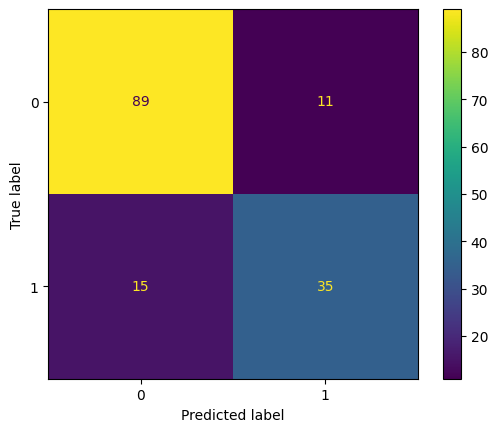

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

False Positive is more serious Because the system thinks the student will pass, so they may not receive intervention, even though they are actually at risk of failing

## 14. Try your own students

Create 5 hypothetical students.

Example:

```text
hours_studied = 8
attendance = 92
previous_score = 78
```

Ask the neural network to predict their probability of passing.

Try some borderline cases too.

### Challenge

Can you find a student for whom the model is uncertain, such as a prediction around:

```text
0.45–0.55
```

Why might the model be uncertain?


In [37]:
students = np.array([
    [8, 92, 78],
    [2, 60, 45],
    [6, 85, 70],
    [4, 75, 55],
    [5, 78, 60]
])

students_scaled = scaler.transform(students)
probabilities = model.predict(students_scaled)

for i, prob in enumerate(probabilities):
    print(f"Student {i+1}: {prob[0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Student 1: 0.73
Student 2: 0.00
Student 3: 0.60
Student 4: 0.04
Student 5: 0.12


C:\Users\Sami\Documents\PROJECTS\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Reflection

Answer these questions in your own words:

1. What is a neuron doing?
2. What is the purpose of a weight?
3. What is a bias?
4. What happens during forward propagation?
5. Why do we need an activation function?
6. Why is sigmoid useful for binary classification?
7. What does binary cross-entropy measure?
8. What happens during backpropagation?
9. What does gradient descent change?
10. What is an epoch?
11. What is a batch?
12. Why do we keep a separate test set?

## Final challenge

Change the architecture and compare:

```text
Model A:
3 → 4 → 1

Model B:
3 → 8 → 4 → 1

Model C:
3 → 32 → 16 → 8 → 1
```

Compare their validation and test performance.

**Question:** Does a bigger network always perform better?


* It takes inputs, processes them, and produces an output
* It tells the network how important each input is.
* It gives the neuron some flexibility to adjust its output
* The inputs move through the network until it produces a prediction
* It helps the network learn more complex patterns.
* It gives us a probability between 0 and 1.
* It measures how far the predicted probability is from the correct answer.
* The network works backward to figure out how each weight contributed to the error.
* It changes the weights to reduce the error.
* One complete pass through the training data.
* A small group of training examples processed at once.
* To see how well the model performs on data it has never seen before.

In [39]:
model_c = Sequential([
    Dense(32, activation="relu", input_shape=(3,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_c.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_c = model_c.fit(
    scaled_x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

test_loss, test_accuracy = model_c.evaluate(scaled_x_test, y_test)

print("Test accuracy:", test_accuracy)

Epoch 1/50


C:\Users\Sami\Documents\PROJECTS\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5500 - loss: 0.6920 - val_accuracy: 0.6778 - val_loss: 0.6698
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7306 - loss: 0.6531 - val_accuracy: 0.7222 - val_loss: 0.6420
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7528 - loss: 0.6102 - val_accuracy: 0.7222 - val_loss: 0.5937
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7639 - loss: 0.5518 - val_accuracy: 0.7111 - val_loss: 0.5501
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7750 - loss: 0.4954 - val_accuracy: 0.7000 - val_loss: 0.5117
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7778 - loss: 0.4532 - val_accuracy: 0.7444 - val_loss: 0.4927
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7778 - loss: 0.4352 - val_accuracy: 0.7444 - val_loss: 0.4885
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7861 - loss: 0.4271 - val_accuracy: 0.7556 - val_loss: 0.4784
Ep

No. A bigger network can learn more complex patterns, but it can also overfit. Sometimes a smaller network performs better.